# Tutorial 3: Model Diagnosis

After training, the key question is: **did the model learn cell-type-specific regulatory patterns?**

The most important diagnostic is whether cells cluster by type in the model's latent spaces. If cell types are nicely clustered in the enhancer and predicted RNA embeddings, that's a good sign that the model learned meaningful biology.

## Setup

In [1]:
import torch
import scanpy as sc

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

We load the preprocessed MuData (which should include cell annotations from Tutorial 1) and the trained model.

In [2]:
import os

data_dir = "../../../../data/deepSCENIC/MM_lines/"
assert os.path.exists(data_dir), "Data directory not found"

# Load preprocessed MuData
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

# Load trained model
model = ds.tl.load_model(data_dir + "weights/converted_model.pt", device=device)

# Verify cell annotations are available (if you have them)
print(f"\nCell annotations: {list(mdata.obs.columns)}")
if "cell_state" in mdata.obs:
    print(f"Cell states: {mdata.obs['cell_state'].value_counts().to_dict()}")

deepscenic.io - INFO - Loaded ../../../../data/deepSCENIC/MM_lines/preprocessed_data.h5mu: 936 cells, 12156 genes, 281820 regions
deepscenic.tl - INFO - Loaded model from ../../../../data/deepSCENIC/MM_lines/weights/converted_model.pt: 11717 genes, 1386 TFs, 273545 regions



Cell annotations: ['cell_line', 'cell_state', 'split']
Cell states: {'INT': 358, 'MEL': 318, 'MES': 260}


```{note}
If you encounter GPU memory errors during inference, reduce the `batch_size` parameter in `ds.tl.to_latent()`. The default processes all cells at once.
```

## Extract Model Embeddings

The model produces several intermediate representations that we can visualize:

- **z_tf**: Latent TF activity (after the encoder)
- **enh_act**: Enhancer/region activity (z_tf multiplied by E1)
- **z_rna**: Predicted gene regulatory signal (enh_act multiplied by E2)

Each of these should show cell-type-specific structure if the model learned well.

In [ ]:
# Extract all embeddings in one pass
# Use batch_size to avoid GPU memory issues
embeddings = ds.tl.to_latent(model, mdata, batch_size=64)

print("Extracted embeddings:")
for name, arr in embeddings.items():
    print(f"  {name}: {arr.shape}")

## Cell-Type Clustering in Latent Spaces

The primary diagnostic: **do cells cluster by type in the model's embedding spaces?**

If cells with the same annotation (e.g., cell state) cluster together, the model has learned biologically meaningful patterns. If cells are randomly mixed, something went wrong.

### TF Activity Space (z_tf)

This is the most direct test of whether the model learned TF activity patterns that distinguish cell types.

### Other Embedding Spaces (Optional)

The z_rna and enh_act embeddings are high-dimensional (~12k and ~280k respectively). If you want to visualize them, use scanpy's PCA + UMAP:

```python
import scanpy as sc

adata_rna = sc.AnnData(embeddings["z_rna"])
adata_rna.obs = mdata.obs.copy()
sc.pp.pca(adata_rna, n_comps=50)
sc.pp.neighbors(adata_rna)
sc.tl.umap(adata_rna)
sc.pl.umap(adata_rna, color="cell_state")
```

In [ ]:
# UMAP of TF activity space - the primary diagnostic
ds.pl.latent_umap(model, mdata, color="cell_state")

## Interpreting Results

**Good signs:**
- Distinct clusters matching your cell type annotations
- Consistent structure across z_tf and z_rna spaces
- Intermediate states (e.g., INT) appearing between major clusters

**Warning signs:**
- Random mixing of cell types → model didn't learn biology
- Only seeing batch effects → need batch correction
- Single blob → training may have collapsed

If clustering looks poor, try:
1. More training epochs
2. Different learning rate
3. Check data preprocessing (are TFs correctly marked?)

## Training Curves (Secondary Check)

If you trained the model yourself (rather than loading a converted legacy model), you can check the training curves:

```python
# Only available for models trained with ds.tl.train()
ds.pl.loss_curves(model)
```

Look for: decreasing loss, train/test curves that don't diverge wildly.

## Next Steps

Now that you've validated your model:

- Extract and analyze the learned GRN: {doc}`04_grn_analysis`
- Simulate perturbation experiments: {doc}`05_perturbation_analysis`

## TF Activity Profiles (Optional Deep Dive)

Once you've confirmed good clustering, you can examine which TFs drive the cell-type differences with a clustered heatmap.

/home/luna.kuleuven.be/u0166574/Desktop/projects/deepSCENIC/src/deepscenic/pl/training/_diagnostics.py:590: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_tf.groupby(groups).mean().T


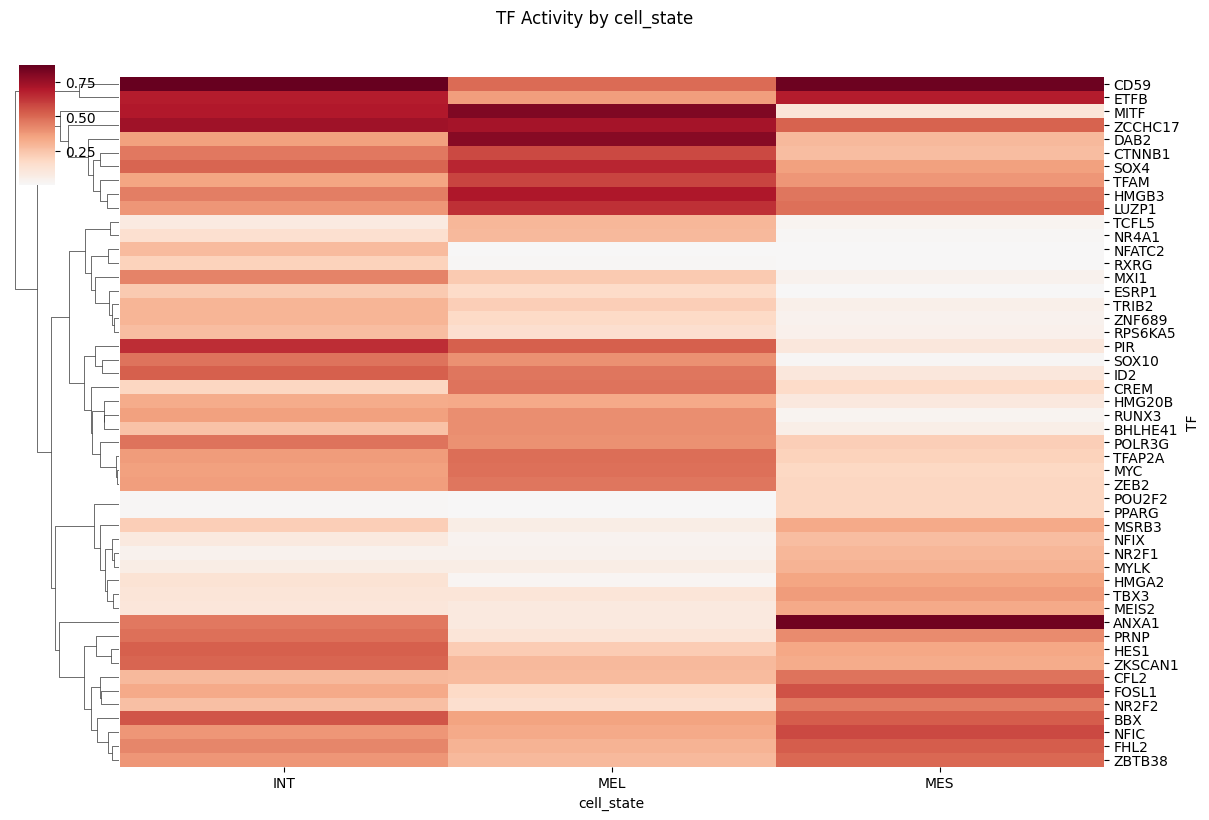

In [7]:
# Show top 50 most variable TFs across cell states
ds.pl.tf_activity_clustermap(model, mdata, groupby="cell_state", top_n_tfs=50)